In [ ]:
import numpy as np
import pandas as pd
from time import time
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings("ignore")
import re
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_curve,auc, roc_curve, classification_report
from sklearn.metrics import average_precision_score, roc_auc_score, precision_score, recall_score
from sklearn.metrics import f1_score
import shap
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("derrickmwiti/google-2019-cluster-sample")

print("Path to dataset files:", path)

100%|██████████| 96.7M/96.7M [00:00<00:00, 107MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/derrickmwiti/google-2019-cluster-sample/versions/1


In [ ]:
df_full = pd.read_csv("/root/.cache/kagglehub/datasets/derrickmwiti/google-2019-cluster-sample/versions/1/borg_traces_data.csv", index_col=0)
df_full.head()

,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,resource_request,...,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed
0,0,2,94591244395,3,1,200,0,144,168846390496,"{'cpus': 0.020660400390625, 'memory': 0.014434...",...,0.014435,0.000415,NaN,NaN,1.0,[0.00314331 0.00381088 0.00401306 0.00415039 0...,[0.00535583 0.00541687 0.00548553 0.00554657 0...,7,FAIL,1
1,2517305308183,2,260697606809,2,0,360,221495397286,335,85515092,"{'cpus': 0.00724029541015625, 'memory': 0.0013...",...,0.000000,0.000000,NaN,NaN,1.0,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,7,FAIL,1
2,195684022913,6,276227177776,2,0,103,0,376,169321752432,"{'cpus': 0.048583984375, 'memory': 0.004165649...",...,0.010422,0.000235,0.939919,0.001318,1.0,[0.01344299 0.01809692 0.0201416 0.02246094 0...,[0.02902222 0.02929688 0.0295105 0.0296936 0...,7,SCHEDULE,0
3,0,2,10507389885,3,0,200,0,1977,178294817221,"{'cpus': 0.0704345703125, 'memory': 0.04162597...",...,0.041626,0.000225,1.359102,0.007643,1.0,[0.03704834 0.04125977 0.04290771 0.04425049 0...,[0.05535889 0.05584717 0.05633545 0.05718994 0...,8,FAIL,1
4,1810627494172,3,25911621841,2,0,0,0,3907,231364893292,"{'cpus': 0.00244903564453125, 'memory': 0.0002...",...,0.000272,0.000010,NaN,NaN,1.0,[0. 0. 0. 0. 0...,[0.00041485 0.00041485 0.00041485 0.00041485 0...,2,FINISH,0


In [ ]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 405894 entries, 0 to 405893
Data columns (total 33 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   time                             405894 non-null  int64  
 1   instance_events_type             405894 non-null  int64  
 2   collection_id                    405894 non-null  int64  
 3   scheduling_class                 405894 non-null  int64  
 4   collection_type                  405894 non-null  int64  
 5   priority                         405894 non-null  int64  
 6   alloc_collection_id              405894 non-null  int64  
 7   instance_index                   405894 non-null  int64  
 8   machine_id                       405894 non-null  int64  
 9   resource_request                 405120 non-null  object 
 10  constraint                       405894 non-null  object 
 11  collections_events_type          405894 non-null  int64  
 12  user   

In [ ]:
df_full["failed"].value_counts()

,count
failed,
0,313216
1,92678


The full dataset of 405,894 rows causes the notebook to crash from too much memory use, so I have to use a subset of the data. I am randomly sampling data from both the failed and not-failed rows to maintain the fail/no-fail proportions in the resultant dataset.

In [ ]:
scale = 5
df_0 = df_full[df_full["failed"] == 0].sample(int(df_full["failed"].value_counts()[0]) // scale)
df_1 = df_full[df_full["failed"] == 1].sample(int(df_full["failed"].value_counts()[1]) // scale)
df = pd.concat([df_0, df_1], ignore_index=True)
df["failed"].value_counts()

,count
failed,
0,62643
1,18535


In [ ]:
df[["time", "vertical_scaling", "start_time", "end_time", "assigned_memory", "page_cache_memory",
    "cycles_per_instruction", "memory_accesses_per_instruction", "sample_rate"]].describe()

,time,vertical_scaling,start_time,end_time,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate
count,8.117800e+04,81003.000000,8.117800e+04,8.117800e+04,81178.000000,81178.000000,56241.000000,56241.000000,81178.000000
mean,1.106171e+12,1.859055,1.241588e+12,1.241800e+12,0.008675,0.000396,2.185904,0.010728,0.999238
std,8.301038e+11,0.756002,7.970407e+11,7.970459e+11,0.024278,0.000546,1.236489,0.007774,0.009882
min,0.000000e+00,1.000000,6.000000e+08,9.000000e+08,0.000000,0.000000,0.400149,0.000159,0.454545
25%,2.733780e+11,1.000000,5.247000e+11,5.250000e+11,0.000196,0.000008,1.070513,0.004329,1.000000
50%,1.089309e+12,2.000000,1.274550e+12,1.274674e+12,0.002632,0.000228,1.918681,0.009506,1.000000
75%,1.775749e+12,2.000000,1.944000e+12,1.944300e+12,0.006615,0.000539,3.156894,0.016435,1.000000
max,2.678862e+12,3.000000,2.678400e+12,2.678700e+12,0.269043,0.006042,7.779392,0.084292,1.000000


In [ ]:
df_categorical = ["scheduler", "instance_events_type", "collection_id", "scheduling_class",
                  "collection_type", "priority", "alloc_collection_id", "instance_index", "machine_id",
                  "resource_request", "constraint", "collections_events_type", "user", "collection_name",
                  "collection_logical_name", "start_after_collection_ids", "average_usage",
                  "maximum_usage", "random_sample_usage", "cpu_usage_distribution",
                  "tail_cpu_usage_distribution", "cluster", "event"]

for i in df_categorical:
    df[i] = df[i].astype("object")

df[["scheduler", "instance_events_type", "collection_id", "scheduling_class", "collection_type",
    "priority", "alloc_collection_id", "instance_index", "machine_id", "resource_request",
   ]].describe(include="O")

,scheduler,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,resource_request
count,81003.0,81178,81178,81178,81178,81178,81178,81178,81178,81023
unique,2.0,8,2506,4,2,22,359,15148,57562,8227
top,0.0,3,755686677250,2,0,103,0,17,120867047402,"{'cpus': 0.00566864013671875, 'memory': 0.0026..."
freq,51021.0,18629,1975,26166,74048,18901,63275,1636,5,5013


In [ ]:
df[["constraint", "collections_events_type", "user", "collection_name", "collection_logical_name",
    "start_after_collection_ids", "average_usage", "maximum_usage", "random_sample_usage",
    "cpu_usage_distribution", "tail_cpu_usage_distribution", "cluster", "event"]].describe(include="O")

,constraint,collections_events_type,user,collection_name,collection_logical_name,start_after_collection_ids,average_usage,maximum_usage,random_sample_usage,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event
count,81178,81178,81178,81178,81178,81178,81178,81178,81178,81178,81178,81178,81178
unique,57,8,584,1949,1380,31,3018,3021,1820,2889,2873,8,8
top,[],3,DrrEIEWkWuW7RrZwpHLCN0k0A2J0usJeyt3wtqzZ7Kk=,AbfLM/72wWE5g5N3WQHZ1wC0R8mV5trtLcKtgLVs88I=,mOIaNf8mXWKMT1ODsgfz3yhpFBedgNmcMaskvu55SBc=,[],"{'cpus': 0.0, 'memory': 9.5367431640625e-07}","{'cpus': 0.0, 'memory': 9.5367431640625e-07}","{'cpus': 0.0, 'memory': None}",[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.],[0. 0. 0. 0. 0. 0. 0. 0. 0.],6,FINISH
freq,59601,18629,13628,3535,9802,80092,3517,3481,9269,6642,6642,11824,18629


In [ ]:
df.columns

Index(['time', 'instance_events_type', 'collection_id', 'scheduling_class',
       'collection_type', 'priority', 'alloc_collection_id', 'instance_index',
       'machine_id', 'resource_request', 'constraint',
       'collections_events_type', 'user', 'collection_name',
       'collection_logical_name', 'start_after_collection_ids',
       'vertical_scaling', 'scheduler', 'start_time', 'end_time',
       'average_usage', 'maximum_usage', 'random_sample_usage',
       'assigned_memory', 'page_cache_memory', 'cycles_per_instruction',
       'memory_accesses_per_instruction', 'sample_rate',
       'cpu_usage_distribution', 'tail_cpu_usage_distribution', 'cluster',
       'event', 'failed'],
      dtype='object')

In [ ]:
df.dropna(subset=["resource_request"], axis="rows", inplace=True)
df.reset_index(drop=True, inplace=True)

def split_cell(data):
    number = re.compile(r"[0-9]")
    if type(data) != float:
        data = data.split(": ")
        cpu = data[1]
        cpu = cpu.split(",")[0]
        cpu = float(cpu)

        memory = data[2].split("}")
        if number.match(memory[0]):
            memory = float(memory[0])
        else:
            memory = np.nan
    else:
        cpu, memory = np.nan, np.nan

    return [cpu, memory]

dff = df.drop(["resource_request", "vertical_scaling", "scheduler", "cycles_per_instruction",
               "start_after_collection_ids", "average_usage", "maximum_usage", "random_sample_usage",
               "cpu_usage_distribution", "tail_cpu_usage_distribution", "resource_request",
               "memory_accesses_per_instruction", "constraint", "event",
               "collection_type", "collections_events_type", "instance_events_type"], axis=1)

In [ ]:
dff["rr_cpu"] = df["resource_request"].apply(lambda x: split_cell(x)[0])
dff["rr_memory"] = df["resource_request"].apply(lambda x: split_cell(x)[1])

dff["au_cpu"] = df["average_usage"].apply(lambda x: split_cell(x)[0])
dff["au_memory"] = df["average_usage"].apply(lambda x: split_cell(x)[1])

dff["rsu_cpu"] = df["random_sample_usage"].apply(lambda x: split_cell(x)[0])

dff["mu_cpu"] = df["maximum_usage"].apply(lambda x: split_cell(x)[0])
dff["mu_memory"] = df["maximum_usage"].apply(lambda x: split_cell(x)[1])

del df

In [ ]:
dff.dropna(inplace=True)
dff.reset_index(drop=True, inplace=True)

categorical_columns = ["user", "collection_name", "collection_logical_name",
                       "scheduling_class", "cluster"]

dffX = dff.drop(["collection_id","machine_id", "alloc_collection_id","failed"], axis=1)

y = dff["failed"]

In [ ]:
del dff

X = pd.get_dummies(dffX, columns=categorical_columns, sparse=True)

del dffX

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X.sample()

,time,priority,instance_index,start_time,end_time,assigned_memory,page_cache_memory,sample_rate,rr_cpu,rr_memory,...,scheduling_class_2,scheduling_class_3,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,cluster_8
19358,72626646553,0,161,72600000000,72623000000,0.000255,0.000051,1.0,0.040527,0.000255,...,False,True,False,False,False,False,False,False,False,True


## Logistic Regression

In [ ]:
start = time()
lad = AdaBoostClassifier(
    LogisticRegression(solver='liblinear',class_weight='balanced'),
    n_estimators=500,
    learning_rate=1.5,
    algorithm="SAMME",
)

lad.fit(X_train, y_train)
end = time()
duration = round((end - start), 2)

lad_predictions = lad.predict(X_test)

print(classification_report(y_test, lad_predictions), "\n", duration, "seconds")

              precision    recall  f1-score   support

           0       0.84      0.61      0.71     18537
           1       0.32      0.61      0.42      5492

    accuracy                           0.61     24029
   macro avg       0.58      0.61      0.56     24029
weighted avg       0.72      0.61      0.64     24029
 
 52.67 seconds


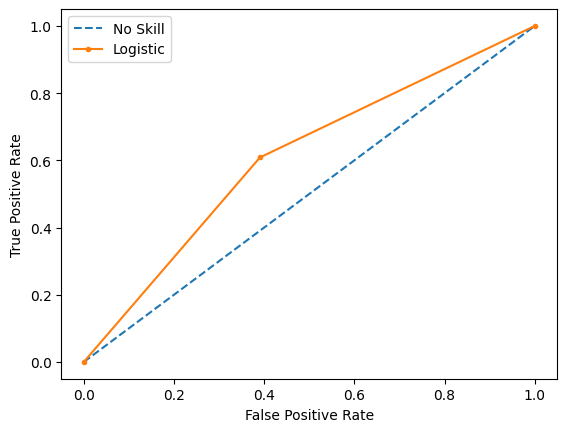

In [ ]:
# plot no skill roc curve
plt.plot([0, 1], [0, 1], linestyle='--', label='No Skill')
# calculate roc curve for model
fpr, tpr, _ = roc_curve(y_test, lad_predictions)
# plot model roc curve
plt.plot(fpr, tpr, marker='.', label='Logistic')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [ ]:
y_pred_proba = lad.predict_proba(X_test)[::,1]
auc = roc_auc_score(y_test, y_pred_proba)
auc

np.float64(0.6089756374340156)

Making a copy of the indepentent variables so I can use a section of that for the explainable portion. I pick just the first 1000 rows to use, mostly because of how long it takes to calculate the shap values. Times to calculate values for each of the three models are shown below each calculation.

In [ ]:
X_copy = X.copy()
for i in X_copy.columns:
    X_copy[i] = X_copy[i].astype("float32")
X_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80095 entries, 0 to 80094
Columns: 3888 entries, time to cluster_8
dtypes: float32(3888)
memory usage: 1.2 GB


In [ ]:
explainer_lr = shap.Explainer(lad.predict, X_copy.values[:1000])

In [ ]:
start = time()
shap_values_lr = explainer_lr(X_copy.values[:1000])
end = time()
duration = round((end - start), 2)

print(f"It took {duration} seconds to calculate the shap values for the Logistic Regression model.")

PermutationExplainer explainer: 1001it [21:42,  1.31s/it]

It took 1303.31 seconds to calculate the shap values for the Logistic Regression model.


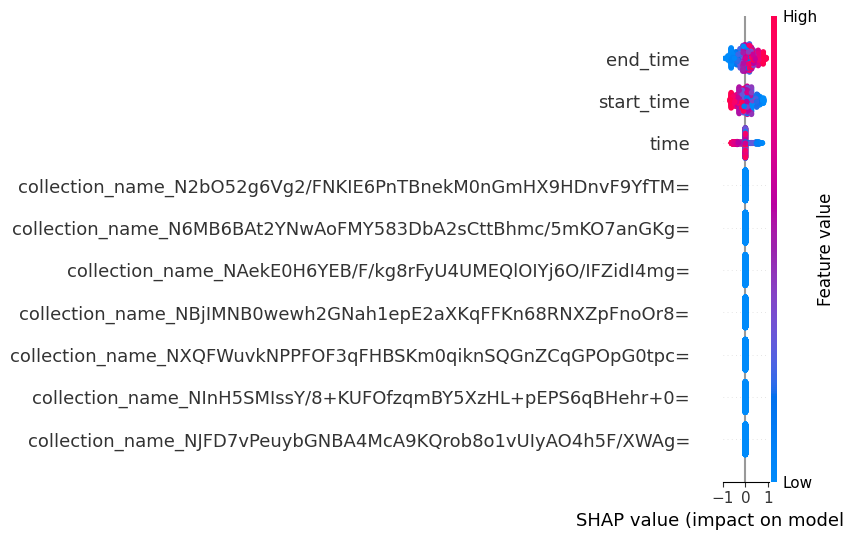

In [ ]:
shap.summary_plot(shap_values_lr, X_copy[:1000], max_display=10, feature_names=X_copy.columns)

I get the prediction of some of the values so that I can use one of each fail/no-fail prediction from it to show the sample waterfall charts following. The output will change with each running of the notebook from top to bottom since I randomly sample the data to pick just some of it due to memory constraints on using the entire dataset.

In [ ]:
lad.predict(X_copy[:10])

array([0, 1, 1, 1, 0, 0, 1, 1, 0, 0])

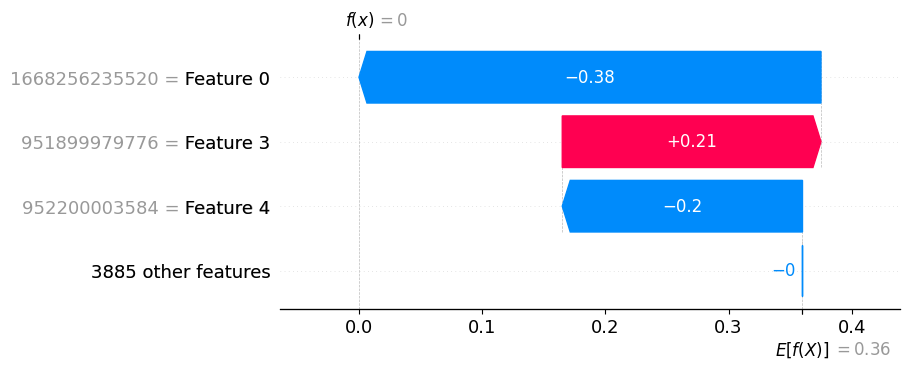

In [ ]:
shap.plots.waterfall(shap_values_lr[0], max_display=4)

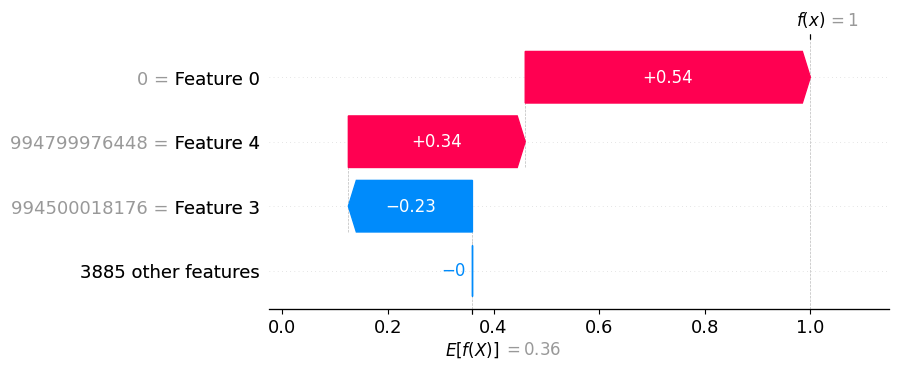

In [ ]:
shap.plots.waterfall(shap_values_lr[1], max_display=4)

## Random Forest

In [ ]:
start = time()
rad = AdaBoostClassifier(
    RandomForestClassifier(max_depth=1, class_weight="balanced"),
    n_estimators=500,
    learning_rate=1.5,
    algorithm="SAMME",
)

rad.fit(X_train, y_train)
end = time()
duration = round((end - start), 2)

rad_predictions = rad.predict(X_test)

print(classification_report(y_test, rad_predictions), "\n", duration, "seconds")

              precision    recall  f1-score   support

           0       0.84      0.92      0.88     18537
           1       0.60      0.41      0.49      5492

    accuracy                           0.80     24029
   macro avg       0.72      0.67      0.68     24029
weighted avg       0.79      0.80      0.79     24029
 
 98.07 seconds


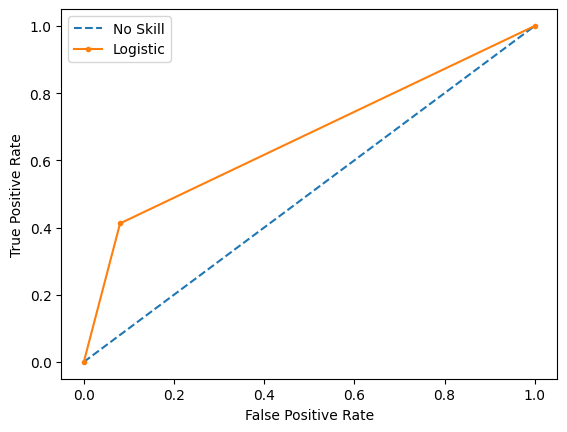

In [ ]:
# plot no skill roc curve
plt.plot([0, 1], [0, 1], linestyle='--', label='No Skill')
# calculate roc curve for model
fpr, tpr, _ = roc_curve(y_test, rad_predictions)
# plot model roc curve
plt.plot(fpr, tpr, marker='.', label='Logistic')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [ ]:
y_pred_proba = rad.predict_proba(X_test)[::,1]
auc = roc_auc_score(y_test, y_pred_proba)
auc

np.float64(0.784671213860541)

In [ ]:
explainer_rf = shap.Explainer(rad.predict, X_copy.values[:1000])

In [ ]:
start = time()
shap_values_rf = explainer_rf(X_copy.values[:1000])
end = time()
duration = round((end - start), 2)

print(f"It took {duration} seconds to calculate the shap values for the Random Forest model.")

PermutationExplainer explainer: 1001it [25:46,  1.56s/it]

It took 1546.72 seconds to calculate the shap values for the Random Forest model.


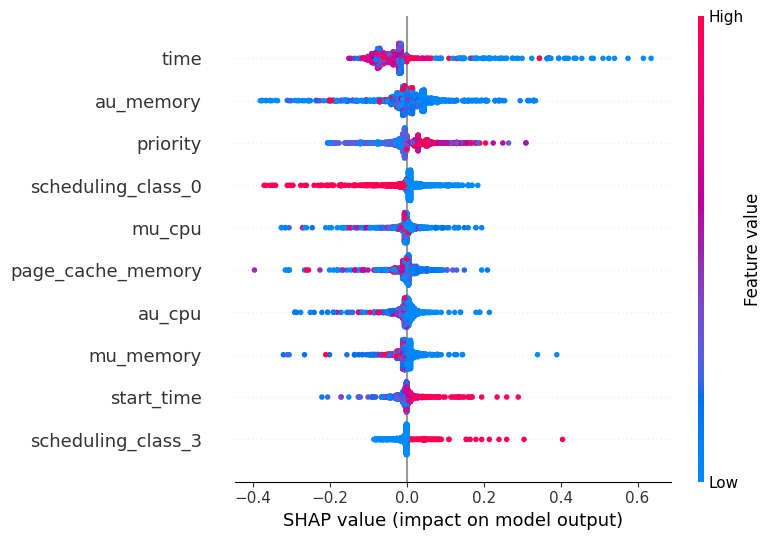

In [ ]:
shap.summary_plot(shap_values_rf, X_copy[:1000], max_display=10, feature_names=X_copy.columns)

I get the prediction of some of the values so that I can use one of each fail/no-fail prediction from it to show the sample waterfall charts following. The output will change with each running of the notebook from top to bottom since I randomly sample the data to pick just some of it due to memory constraints on using the entire dataset.

In [ ]:
rad.predict(X_copy[:10])

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

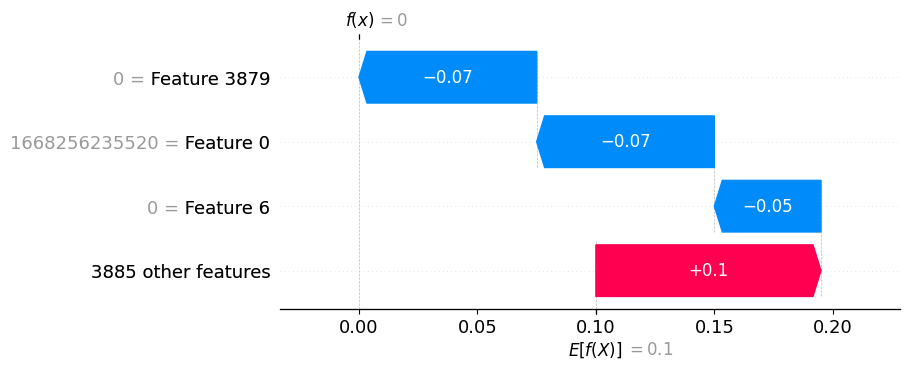

In [ ]:
shap.plots.waterfall(shap_values_rf[0], max_display=4)

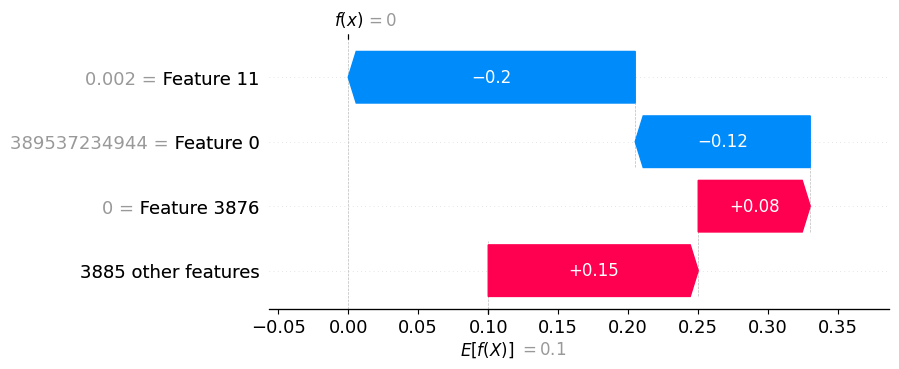

In [ ]:
shap.plots.waterfall(shap_values_rf[3], max_display=4)

## Decision Tree

In [ ]:
start = time()
dad = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1, class_weight="balanced"),
    n_estimators=500,
    learning_rate=1.5,
    algorithm="SAMME",
)

dad.fit(X_train, y_train)
end = time()
duration = round((end - start), 2)

dad_predictions = dad.predict(X_test)

print(classification_report(y_test, dad_predictions), "\n", duration, "seconds")

              precision    recall  f1-score   support

           0       0.84      0.94      0.89     18537
           1       0.65      0.39      0.49      5492

    accuracy                           0.81     24029
   macro avg       0.75      0.66      0.69     24029
weighted avg       0.80      0.81      0.80     24029
 
 62.14 seconds


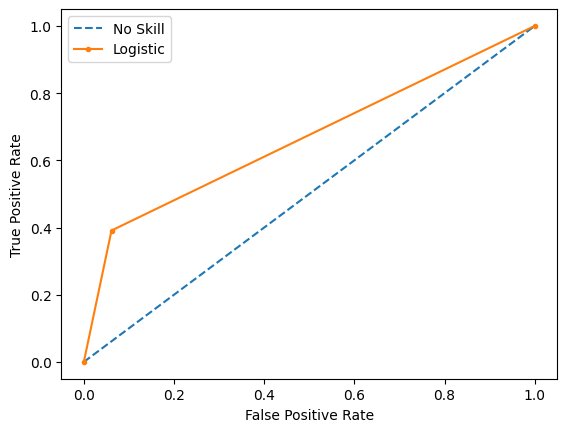

In [ ]:
# plot no skill roc curve
plt.plot([0, 1], [0, 1], linestyle='--', label='No Skill')
# calculate roc curve for model
fpr, tpr, _ = roc_curve(y_test, dad_predictions)
# plot model roc curve
plt.plot(fpr, tpr, marker='.', label='Logistic')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [ ]:
y_pred_proba = dad.predict_proba(X_test)[::,1]
auc = roc_auc_score(y_test, y_pred_proba)
auc

np.float64(0.6648946550905197)

In [ ]:
explainer_dt = shap.Explainer(dad.predict, X_copy.values[:1000])

In [ ]:
start = time()
shap_values_dt = explainer_dt(X_copy.values[:1000])
end = time()
duration = round((end - start), 2)

print(f"It took {duration} seconds to calculate the shap values for the Decision Tree model.")

PermutationExplainer explainer: 1001it [21:57,  1.33s/it]

It took 1317.48 seconds to calculate the shap values for the Decision Tree model.


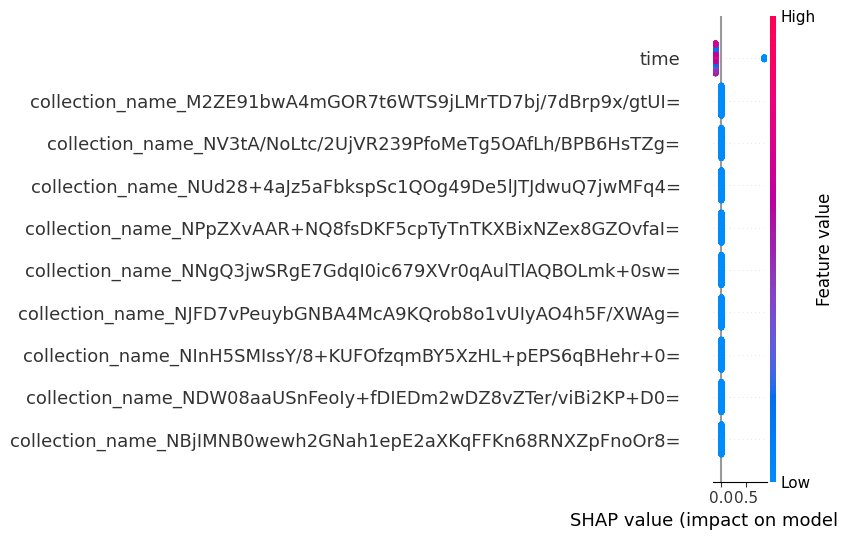

In [ ]:
shap.summary_plot(shap_values_dt, X_copy[:1000], max_display=10, feature_names=X_copy.columns)

I get the prediction of some of the values so that I can use one of each fail/no-fail prediction from it to show the sample waterfall charts following. The output will change with each running of the notebook from top to bottom since I randomly sample the data to pick just some of it due to memory constraints on using the entire dataset.

In [ ]:
dad.predict(X_copy[:10])

array([0, 1, 0, 0, 0, 0, 1, 0, 0, 0])

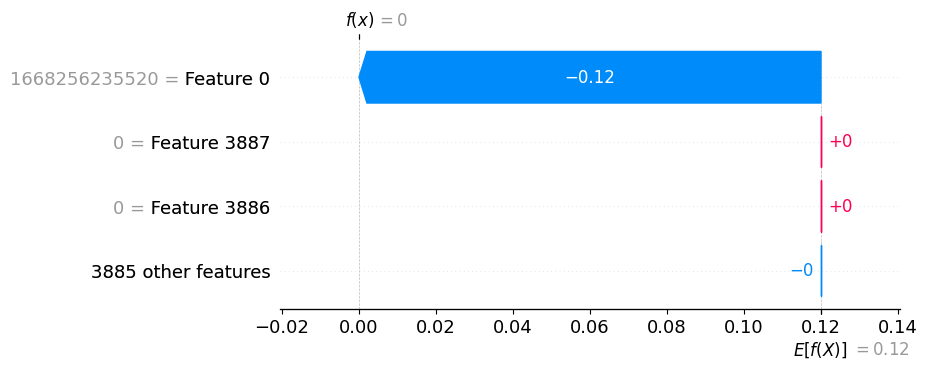

In [ ]:
shap.plots.waterfall(shap_values_dt[0], max_display=4)

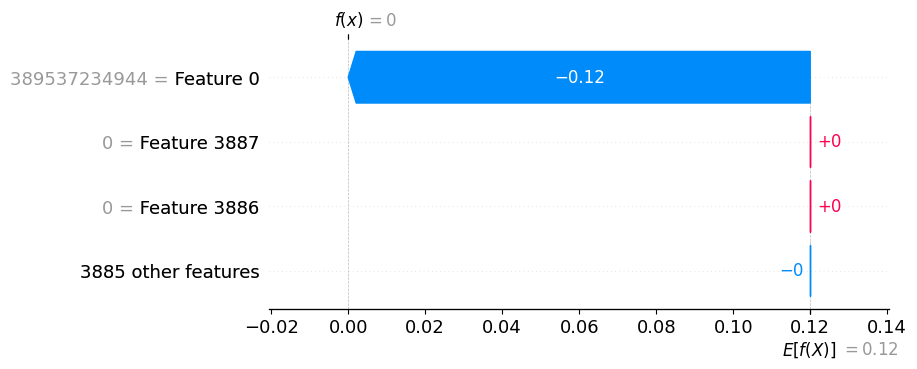

In [ ]:
shap.plots.waterfall(shap_values_dt[3], max_display=4)